# 02 – Modeling

**Goal:** Build the preprocessing pipeline, compare several models, tune
their hyperparameters and save the best pipeline.

- **Input:** `data/clean.csv` (created by `01_eda.ipynb`)
- **Output:** `models/personality_pipeline.joblib` (not committed to Git)
- **Main metric:** `f1_macro`
- **Random state:** `42` everywhere (taken from `src/config.py`)

> Run `01_eda.ipynb` first. Run this notebook from the `notebooks/`
> folder.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

# The notebook lives in notebooks/, so the project root is made importable
sys.path.insert(0, str(Path.cwd().parent))

from src import config  # noqa: E402

print(f"Random state: {config.RANDOM_STATE}")

Random state: 42


## 2. Load the cleaned data and split it

In [2]:
clean_df = pd.read_csv(config.CLEAN_DATA_PATH)
print(f"Rows: {clean_df.shape[0]:,} | Columns: {clean_df.shape[1]}")

# The feature order is fixed by the config and reused by the app later
X = clean_df[config.FEATURE_COLUMNS]
y = clean_df[config.TARGET_COLUMN]

Rows: 19,514 | Columns: 23


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config.TEST_SIZE,
    stratify=y,  # keep the class proportions in both parts
    random_state=config.RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 15,611 rows | Test: 3,903 rows


In [4]:
class_share = pd.DataFrame(
    {
        "full_%": y.value_counts(normalize=True) * 100,
        "train_%": y_train.value_counts(normalize=True) * 100,
        "test_%": y_test.value_counts(normalize=True) * 100,
    }
).round(2)
print(class_share)

# The stratified split must preserve the class proportions closely
assert (class_share["train_%"] - class_share["full_%"]).abs().max() < 0.1
assert (class_share["test_%"] - class_share["full_%"]).abs().max() < 0.1

                 full_%  train_%  test_%
target                                  
Moderate          42.84    42.84   42.84
Resilient         31.28    31.28   31.28
Overcontroller    14.41    14.41   14.40
Undercontroller   11.48    11.48   11.48


The data is split once into **80 % training** and **20 % test** data.
The split is **stratified**, so every class has (almost) the same share in
both parts. This is important because the classes are imbalanced.

The test set is only used for the final evaluation. Model selection and
hyperparameter tuning are done with cross-validation on the training
data.

## 3. Preprocessing sanity check

Before any model is trained, we check that the preprocessing behaves as
intended: it must be fitted on the **training data only** (no data leakage)
and it must be able to handle raw input with exactly the columns defined in
`config.FEATURE_COLUMNS`.

In [5]:
import numpy as np

from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor()

# Fit on the training data only, then apply the fitted step to both parts
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print(f"Train shape: {X_train_transformed.shape}")
print(f"Test shape:  {X_test_transformed.shape}")
print(f"Features:    {list(feature_names)}")

Train shape: (15611, 26)
Test shape:  (3903, 26)
Features:    ['numeric__N1', 'numeric__N2', 'numeric__N3', 'numeric__N4', 'numeric__N5', 'numeric__N6', 'numeric__N7', 'numeric__N8', 'numeric__N9', 'numeric__N10', 'numeric__E1', 'numeric__E3', 'numeric__E4', 'numeric__E5', 'numeric__E7', 'numeric__E9', 'numeric__E10', 'numeric__A4', 'numeric__C4', 'numeric__age', 'categorical__gender_Female', 'categorical__gender_Male', 'categorical__gender_Other', 'categorical__hand_Both', 'categorical__hand_Left', 'categorical__hand_Right']


In [6]:
# 19 questions + age + 3 gender dummies + 3 hand dummies
assert X_train_transformed.shape[1] == 26
assert not np.isnan(X_train_transformed).any()
assert not np.isnan(X_test_transformed).any()

# The input columns (names and order) must match the config exactly
assert list(preprocessor.feature_names_in_) == config.FEATURE_COLUMNS

# The raw input must have numeric dtypes for the numeric columns
assert all(pd.api.types.is_numeric_dtype(X_train[column])
           for column in config.NUMERIC_COLUMNS)
print("Structure checks passed.")

Structure checks passed.

In [7]:
# Scaling: the fitted scaler centers the TRAINING data exactly ...
train_means = X_train_transformed[:, :20].mean(axis=0)
train_stds = X_train_transformed[:, :20].std(axis=0)
assert np.allclose(train_means, 0, atol=1e-8)
assert np.allclose(train_stds, 1, atol=1e-8)

# ... but not the test data, which proves that nothing was fitted on it
test_means = X_test_transformed[:, :20].mean(axis=0)
assert not np.allclose(test_means, 0, atol=1e-8)
print(f"Largest |mean| in the test data: {np.abs(test_means).max():.3f}")

Largest |mean| in the test data: 0.036


In [8]:
# One-hot encoding: exactly one dummy is active per feature group
gender_dummies = X_train_transformed[:, 20:23]
hand_dummies = X_train_transformed[:, 23:26]
assert (gender_dummies.sum(axis=1) == 1).all()
assert (hand_dummies.sum(axis=1) == 1).all()

# An unseen category must not raise an error (all dummies stay 0)
unseen_row = X_train.iloc[[0]].copy()
unseen_row["gender"] = "Unknown"
unseen_transformed = preprocessor.transform(unseen_row)
assert unseen_transformed[0, 20:23].sum() == 0
print("Encoding checks passed.")

Encoding checks passed.


The preprocessing works as intended:

- 26 output features (19 questions, age, 3 gender and 3 hand dummies)
- standardized on the training data only, so no information from the test
  set leaks into the model
- unseen categories are handled gracefully
- the expected input columns match `config.FEATURE_COLUMNS` exactly, which is
  the contract between the notebooks and the Streamlit app

## 4. Baselines

Before comparing real models we need a **lower bound**. Dummy classifiers
ignore the questionnaire answers completely. Every real model must beat
them clearly, otherwise it has not learned anything.

All scores in this section are **5-fold stratified cross-validation scores
on the training data**. The test set stays untouched until the final
evaluation. All models use the same folds (see `src/evaluation.py`).

In [9]:
from sklearn.base import BaseEstimator
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from src.evaluation import cross_validate_model
from src.preprocessing import build_preprocessor


def make_pipeline(model: BaseEstimator) -> Pipeline:
    """Combine a fresh preprocessing step with the given model.

    A new preprocessor is created for every call, so that pipelines never
    share fitted state.
    """
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model),
        ]
    )

In [10]:
baselines = {
    "Dummy (most frequent class)": make_pipeline(
        DummyClassifier(strategy="most_frequent")
    ),
    "Dummy (random by class share)": make_pipeline(
        DummyClassifier(strategy="stratified",
                        random_state=config.RANDOM_STATE)
    ),
}

baseline_results = pd.DataFrame(
    {name: cross_validate_model(pipeline, X_train, y_train)
     for name, pipeline in baselines.items()}
).T
baseline_results.round(3)

,cv_f1_macro,cv_f1_macro_std,cv_accuracy,train_f1_macro,fit_time_s
Dummy (most frequent class),0.150,0.000,0.428,0.15,0.027
Dummy (random by class share),0.248,0.004,0.312,0.25,0.027


**Interpretation**

- Always predicting the largest class (*Moderate*) gives an accuracy of
  about 0.43 but an `f1_macro` of only about **0.15**, because the other
  three classes are never predicted.
- Guessing randomly according to the class shares gives an `f1_macro` of
  about **0.25**.
- Every real model must therefore clearly exceed an `f1_macro` of about
  0.25. The accuracy of the dummy models also shows why accuracy alone is
  a poor metric for this imbalanced problem.

## 5. Candidate models (default hyperparameters)

Three models from different families are compared. All of them are wrapped
in the same pipeline (preprocessing + model) and use `random_state=42`:

| Model | Family | Why it is interesting |
| --- | --- | --- |
| Logistic Regression | linear | Simple, fast, well interpretable. Works well if the classes are (almost) linearly separable. |
| Random Forest | bagged decision trees | Robust, captures non-linear effects and interactions, few assumptions. |
| Hist Gradient Boosting | boosted decision trees | Usually the strongest model on tabular data, but needs careful tuning. |

In this step all models still use their **default hyperparameters**
(except `max_iter` for the logistic regression, so that the solver
converges). This shows how good each family is *before* tuning.

In [11]:
from sklearn.ensemble import (HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression

candidates = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=1000, random_state=config.RANDOM_STATE)
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(random_state=config.RANDOM_STATE)
    ),
    "Hist Gradient Boosting": make_pipeline(
        HistGradientBoostingClassifier(random_state=config.RANDOM_STATE)
    ),
}

for name, pipeline in candidates.items():
    print(f"{name}: {[step_name for step_name, _ in pipeline.steps]}")

Logistic Regression: ['preprocessor', 'model']
Random Forest: ['preprocessor', 'model']
Hist Gradient Boosting: ['preprocessor', 'model']


## 6. Comparison without tuning

The three candidates are evaluated with the same 5-fold stratified
cross-validation as the baselines. The table also contains the mean
**training** `f1_macro` of the folds. A large gap to the validation score
indicates overfitting.

In [12]:
candidate_results = pd.DataFrame(
    {name: cross_validate_model(pipeline, X_train, y_train)
     for name, pipeline in candidates.items()}
).T

untuned_comparison = (
    pd.concat([baseline_results, candidate_results])
    .sort_values("cv_f1_macro", ascending=False)
)
untuned_comparison.round(3)

,cv_f1_macro,cv_f1_macro_std,cv_accuracy,train_f1_macro,fit_time_s
Hist Gradient Boosting,0.797,0.009,0.858,0.936,1.718
Logistic Regression,0.767,0.007,0.854,0.770,0.415
Random Forest,0.743,0.004,0.836,1.000,1.336
Dummy (random by class share),0.248,0.004,0.312,0.250,0.027
Dummy (most frequent class),0.150,0.000,0.428,0.150,0.027


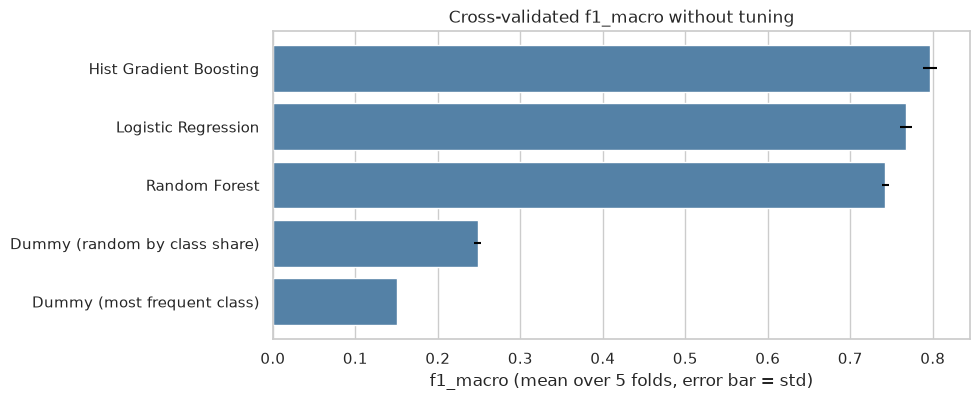

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_data = untuned_comparison.reset_index(names="model")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_data, y="model", x="cv_f1_macro",
            color="steelblue", ax=ax)
ax.errorbar(plot_data["cv_f1_macro"], range(len(plot_data)),
            xerr=plot_data["cv_f1_macro_std"], fmt="none", color="black")
ax.set_title("Cross-validated f1_macro without tuning")
ax.set_xlabel("f1_macro (mean over 5 folds, error bar = std)")
ax.set_ylabel("")
plt.show()

**Interpretation**

- All three models are far above the baselines (`f1_macro` 0.25 at best),
  so the questionnaire contains a lot of information about the personality
  type.
- **Hist Gradient Boosting** is the best model without tuning
  (`f1_macro` ≈ 0.80), followed by **Logistic Regression** (≈ 0.77) and
  **Random Forest** (≈ 0.74). The standard deviations over the folds are
  below 0.01, so the ranking is not caused by random fluctuations.
- The accuracy is higher than the `f1_macro` for every model (0.84–0.86).
  The minority classes *Overcontroller* and *Undercontroller* are harder
  to recognize, and `f1_macro` punishes this.
- The training scores reveal the **overfitting** behavior:
  the Random Forest reaches 1.00 on the training folds, but only 0.74 on
  the validation folds (fully grown trees memorize the data). Hist Gradient
  Boosting (0.94 vs. 0.80) also overfits to some extent. The Logistic
  Regression has almost no gap (0.77 vs. 0.77), so it is limited by its
  simplicity rather than by overfitting.

**Consequence for tuning:** The tree-based models should gain the most
from regularization (e.g. `max_depth`, `min_samples_leaf`,
`l2_regularization`, `learning_rate`). For the logistic regression the
regularization strength `C` and `class_weight` are the most promising
hyperparameters, since `class_weight` directly targets the imbalance that
`f1_macro` is sensitive to.

## 7. Hyperparameter tuning

Each of the three models is tuned with a search on the **training data**.
All searches share the same setup:

- **Metric:** `scoring="f1_macro"`
- **Folds:** the shared stratified 5-fold splitter from `src/evaluation.py`
  (`random_state=42`)
- **Pipeline:** preprocessing and model are tuned together. The scaler
  and encoder are therefore re-fitted inside every fold, so no information
  from the validation fold leaks into the preprocessing.
- **Refit:** the best configuration is refitted on the full training data
  (`best_estimator_`).
- **Reproducibility:** `RandomizedSearchCV` and all models use
  `random_state=42`.

The test set is not touched in this section until the very last step.

In [14]:
import time

import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection._search import BaseSearchCV

from src.evaluation import get_cv_splitter

# Collected results of all searches (filled in the next cells)
tuned_searches = {}
search_times = {}


def summarize_search(search: BaseSearchCV, top: int = 5) -> pd.DataFrame:
    """Return the best parameter combinations of a finished search.

    Args:
        search: A fitted ``GridSearchCV`` or ``RandomizedSearchCV``.
        top: Number of best combinations to show.

    Returns:
        A table with rank, validation score, its standard deviation, the
        training score and the hyperparameters of each combination.
    """
    results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    best = results.head(top)
    scores = best[["rank_test_score", "mean_test_score", "std_test_score",
                   "mean_train_score"]]
    params = pd.DataFrame(list(best["params"]), index=best.index)
    params.columns = [name.replace("model__", "") for name in params.columns]
    return pd.concat([scores, params], axis=1).round(4)

### 7.1 Logistic Regression

The search space is small, so an exhaustive `GridSearchCV` is used:

| Hyperparameter | Values | Idea |
| --- | --- | --- |
| `C` | 0.001, 0.01, 0.1, 1, 10 | inverse regularization strength |
| `class_weight` | `None`, `"balanced"` | weights the rare classes higher, which targets `f1_macro` |

In [15]:
lr_search = GridSearchCV(
    estimator=make_pipeline(
        LogisticRegression(max_iter=1000, random_state=config.RANDOM_STATE)
    ),
    param_grid={
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"],
    },
    scoring="f1_macro",
    cv=get_cv_splitter(),
    n_jobs=-1,
    return_train_score=True,
)

start = time.perf_counter()
lr_search.fit(X_train, y_train)
search_times["Logistic Regression"] = time.perf_counter() - start
tuned_searches["Logistic Regression"] = lr_search

print(f"Best CV f1_macro: {lr_search.best_score_:.4f}")
print(f"Best parameters:  {lr_search.best_params_}")
print(f"Search time:      {search_times['Logistic Regression']:.0f} s")
summarize_search(lr_search)

Best CV f1_macro: 0.7805
Best parameters:  {'model__C': 10, 'model__class_weight': 'balanced'}
Search time:      16 s


,rank_test_score,mean_test_score,std_test_score,mean_train_score,C,class_weight
9,1,0.7805,0.0069,0.7845,10.00,balanced
7,2,0.7800,0.0073,0.7841,1.00,balanced
5,3,0.7780,0.0072,0.7824,0.10,balanced
8,4,0.7678,0.0079,0.7706,10.00,NaN
3,5,0.7675,0.0086,0.7706,0.01,balanced


**Interpretation**

- Best configuration: `C=10` with `class_weight="balanced"`
  (`f1_macro` ≈ 0.781 vs. 0.767 untuned).
- `class_weight="balanced"` is the decisive hyperparameter: the three best
  combinations all use it, while the best combination without it reaches
  only 0.768.
- Weaker regularization (larger `C`) is slightly better. The training score
  (0.785) is almost identical to the validation score (0.781), so the model
  does not overfit. Its limit is the linear decision boundary, which is why
  the gain from tuning is small (+0.013).